**Parallel State Reducers** : it is a type of technique which we mainly used to run the mutiple nodes with diffrent Funtionalities , Parallely or simulteniously

In [2]:
from typing import TypedDict

In [19]:
# Create a State
class StateVar(TypedDict):
  var : int

In [20]:
# Creating nodes

def node1(StateVar):
  StateVar['var']=StateVar['var']+1
  return  StateVar
def node2(StateVar):
  StateVar['var']=StateVar['var']+10
  return  StateVar
def node3(StateVar):
  StateVar['var']=StateVar['var']+100
  return  StateVar

In [23]:
from langgraph.graph import StateGraph, START, END

In [24]:
graph=StateGraph(StateVar)

In [25]:
graph.add_node('N1', node1)
graph.add_node('N2', node2)
graph.add_node('N3', node3)

In [26]:
# Adding Edges
graph.add_edge(START, 'N1')
graph.add_edge('N1', 'N2')
graph.add_edge('N1', 'N3')
graph.add_edge('N2', END)
graph.add_edge('N3', END)

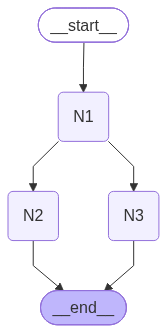

In [27]:
app=graph.compile()
app

In [28]:
app.invoke(
    {
        'var': 1
    }
)

InvalidUpdateError: At key 'var': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

### Meaning of this message mean thar we cannot process Parallel Tasks on multiple Nodes Directly Instead we use `Annotated keys ` For that

Annoted Structure : [ Container, Funtion(dataType)]

In [50]:
from typing import TypedDict , Annotated, List
from operator import add

In [52]:
class StateVar(TypedDict):
  var: Annotated[List[int], add]
  # So it applies that add funtion into Container LIST
  # Since Main Cointainer is LIST here Numbers will be Concatinated at the EnD

In [53]:
# Creating nodes
def node1(StateVar):
  StateVar['var']=[1]
  return  StateVar
def node2(StateVar):
  StateVar['var']=[10]
  return  StateVar
def node3(StateVar):
  StateVar['var']=[100]
  return  StateVar

In [54]:
from langgraph.graph import StateGraph, START, END

In [55]:
graph=StateGraph(StateVar)

In [56]:
graph.add_node('N1', node1)
graph.add_node('N2', node2)
graph.add_node('N3', node3)

In [57]:
# Adding Edges
graph.add_edge(START, 'N1')
graph.add_edge('N1', 'N2')
graph.add_edge('N1', 'N3')
graph.add_edge('N2', END)
graph.add_edge('N3', END)

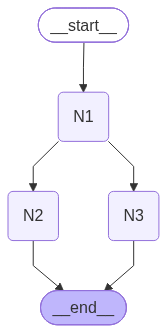

In [58]:
app=graph.compile()
app

In [59]:
app.invoke(
    {
        'var': []
    }
)

{'var': [1, 10, 100]}

In [60]:
app.invoke(
    {
        'var': [10,20,30] # IT JUST APPENDS BCOZ DTYPE IS LIST
    }
)

{'var': [10, 20, 30, 1, 10, 100]}